# 01 — MNIST Provenance, EDA, Data Quality, and Train/Validation/Test Splits (PyTorch)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


The dataset is the first production contract. MNIST contains 28×28 grayscale handwritten digits. The official training archive contains 60,000 labeled images; the official test archive contains 10,000. For fast reproducible teaching and CI, we take a deterministic balanced development subset from the official training pool, then split it into **5,000 training + 1,000 validation**, and take a separate balanced **1,000-image test** subset only from the official test archive.

### Why three splits?
- **Training:** parameters are optimized here.
- **Validation:** hyperparameters, early stopping and model choices are made here.
- **Test:** touched only after all development decisions are frozen.

Using test results to choose a learning rate, architecture, epoch count, or threshold is **test leakage**.


## Code walkthrough — download and deterministically construct the three splits
The code intentionally downloads the same `mnist.npz` archive in all three branches. `balanced_subset` samples the same number of examples per class. `train_test_split(..., stratify=...)` preserves class proportions between train and validation. `random_state=42` makes the split reproducible.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
print("official train", x_train_raw.shape, y_train_raw.shape)
print("official test ", x_test_raw.shape, y_test_raw.shape)
print("train", X_train.shape, y_train.shape)
print("validation", X_val.shape, y_val.shape)
print("test", X_test.shape, y_test.shape)

official train (60000, 28, 28) (60000,)
official test  (10000, 28, 28) (10000,)
train (5000, 784) (5000,)
validation (1000, 784) (1000,)
test (1000, 784) (1000,)


## Code walkthrough — inspect class balance and raw visual evidence
A class-count chart verifies the split contract. The image grid prevents a subtle data mistake: a numerically valid array can still be transposed, corrupted or associated with the wrong labels. In real projects, analogous checks include missingness, duplicate IDs, impossible values, target leakage and timestamp consistency.


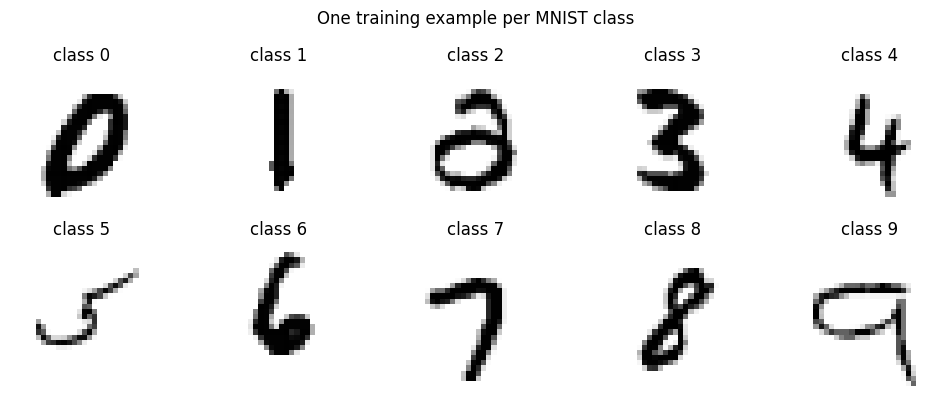

train [500 500 500 500 500 500 500 500 500 500]
validation [100 100 100 100 100 100 100 100 100 100]
test [100 100 100 100 100 100 100 100 100 100]


In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for cls, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(y_train == cls)[0]
    ax.imshow(X_train[idx].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"class {cls}")
    ax.axis("off")
plt.suptitle("One training example per MNIST class")
plt.tight_layout()
plt.show()
for split_name, labels in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(split_name, np.bincount(labels, minlength=10))

## Code walkthrough — explicit data-quality gates
Before any training job, assert invariants rather than assuming them. The checks below verify finite normalized values, valid class IDs, shape consistency and a simple duplicate count. MNIST is unusually clean; enterprise datasets require stronger key, timestamp, schema and leakage checks.


In [3]:
for split_name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_val, y_val),
    ("test", X_test, y_test),
]:
    assert X.ndim == 2 and X.shape[1] == 784
    assert len(X) == len(y)
    assert np.isfinite(X).all()
    assert X.min() >= 0 and X.max() <= 1
    assert set(np.unique(y)).issubset(set(range(10)))
    unique_rows = np.unique(X, axis=0).shape[0]
    print(
        split_name, "samples", len(X), "duplicates within split", len(X) - unique_rows
    )
print(
    "train/validation/test object identities are separate:",
    X_train is not X_val and X_train is not X_test,
)

train samples 5000 duplicates within split 0
validation samples 1000 duplicates within split 0
test samples 1000 duplicates within split 0
train/validation/test object identities are separate: True


## Production inference
The split is not bookkeeping. It defines which information the learning process is allowed to see. A fraud model, medical model, recommendation system or document classifier can appear excellent while being useless if leakage lets future or evaluation-only information enter training.
